In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-11-20 16:23:19.944262: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763655800.152684      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763655800.213661      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
data_dir = "/kaggle/input/gtsrb-german-traffic-sign/Train"
test_dir = "/kaggle/input/gtsrb-german-traffic-sign/Test"

images = []
labels = []

In [3]:
import os
import cv2
import numpy as np

data_dir = "/kaggle/input/gtsrb-german-traffic-sign/Train"

images = []
labels = []

for class_id in range(43):
    class_path = os.path.join(data_dir, str(class_id))
    file_names = sorted(os.listdir(class_path))  # IMPORTANT

    for file in file_names:
        path = os.path.join(class_path, file)
        img = cv2.imread(path)
        if img is None:
            continue
        
        img = cv2.resize(img, (48,48))
        images.append(img)
        labels.append(class_id)

images = np.array(images)
labels = np.array(labels)

print("Loaded:", images.shape, labels.shape)


Loaded: (39209, 48, 48, 3) (39209,)


In [4]:
# # 3. NORMALIZE + ONE-HOT ENCODING
# # =========================================================
images = images.astype('float32') / 255.0


In [5]:
# # 4. TRAIN-TEST SPLIT
# # =========================================================
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

labels_cat = to_categorical(labels, 43)

X_train, X_val, y_train, y_val = train_test_split(
    images, labels_cat, test_size=0.2, stratify=labels, random_state=42)


In [6]:
# # 5. DATA AUGMENTATION
# # =========================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train)


In [7]:
# model
model = tf.keras.Sequential([

    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,3)),
    BatchNormalization(),

    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(43, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763656031.987504      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,332,683 (5.08 MB)

 Trainable params: 1,331,531 (5.08 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [9]:
# 7. COMPILE THE MODEL
# =========================================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Callback Earlystopping

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )]

In [11]:
# 8. TRAIN THE MODEL
# =========================================================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1763656038.054530      60 service.cc:148] XLA service 0x7ec8f0002d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763656038.055333      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763656038.787591      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/491 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.0260 - loss: 4.8584

I0000 00:00:1763656045.204040      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/491 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.3164 - loss: 2.7337 - val_accuracy: 0.7058 - val_loss: 1.0703
Epoch 2/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.7901 - loss: 0.6571 - val_accuracy: 0.9472 - val_loss: 0.3819
Epoch 3/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.9064 - loss: 0.3028 - val_accuracy: 0.9898 - val_loss: 0.0430
Epoch 4/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9432 - loss: 0.1845 - val_accuracy: 0.9954 - val_loss: 0.0234
Epoch 5/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.9526 - loss: 0.1474 - val_accuracy: 0.9966 - val_loss: 0.0174
Epoch 6/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.9662 - loss: 0.1086 - val_accuracy: 0.9969 - val_loss: 0.0099
Epoch 7/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9728 - loss: 0.0872 - val_accuracy: 0.9920 - val_loss: 0.0288
Epoch 8/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9756 - loss: 0.0785 - val_accurac

In [12]:
# 10. SAVE THE MODEL
# =========================================================
model.save("traffic_sign_classifier.h5")
print("Model saved successfully!")

Model saved successfully!


In [13]:
best_model = model  # use the model already trained
y_pred = best_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n✔ Improved Accuracy:", accuracy_score(y_true, y_pred_classes))
print("\n✔ Precision, Recall, F1:\n")
print(classification_report(y_true, y_pred_classes))

246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

✔ Improved Accuracy: 0.9969395562356542

✔ Precision, Recall, F1:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      1.00       444
           2       1.00      1.00      1.00       450
           3       0.99      0.99      0.99       282
           4       0.99      1.00      1.00       396
           5       0.99      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      0.98      0.99       288
           8       0.98      1.00      0.99       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00   

In [14]:
# 9. EVALUATION (Accuracy, Precision, Recall)
# =========================================================

# Convert validation predictions
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n✔ Accuracy:", accuracy_score(y_true, y_pred_classes))
print("\n✔ Precision, Recall, F1:\n")
print(classification_report(y_true, y_pred_classes))

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

✔ Accuracy: 0.9969395562356542

✔ Precision, Recall, F1:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      1.00       444
           2       1.00      1.00      1.00       450
           3       0.99      0.99      0.99       282
           4       0.99      1.00      1.00       396
           5       0.99      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      0.98      0.99       288
           8       0.98      1.00      0.99       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      1.00  

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


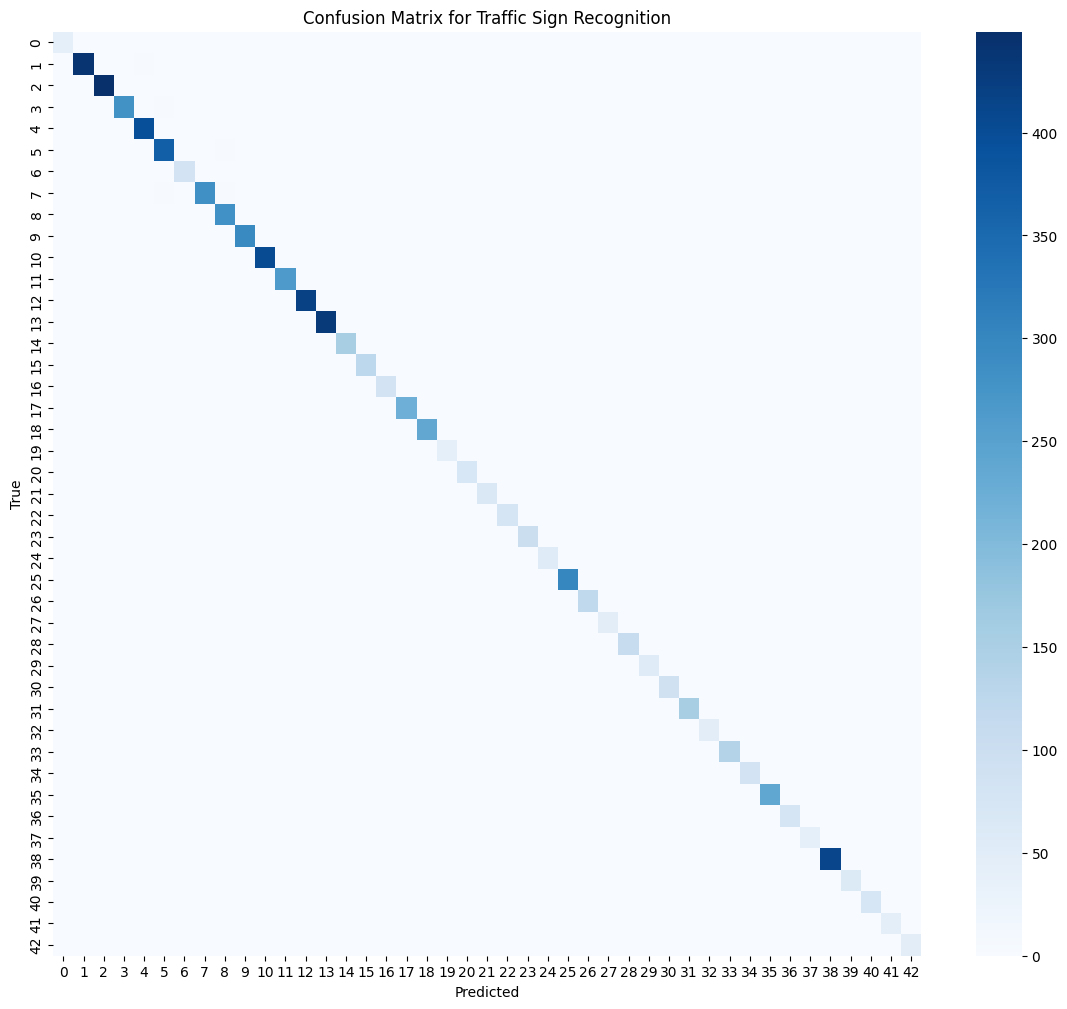

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = best_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix for Traffic Sign Recognition")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


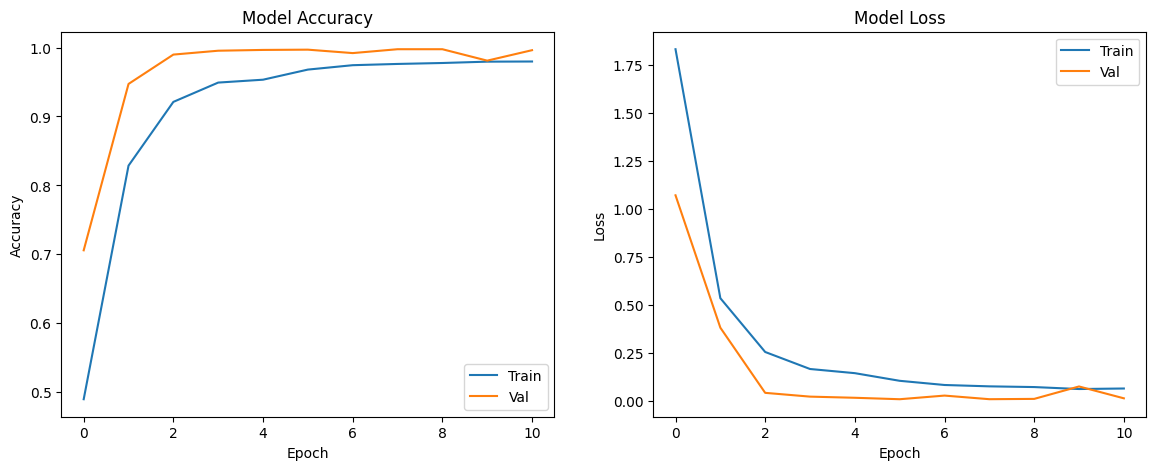

In [16]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Val"])

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Val"])

plt.show()


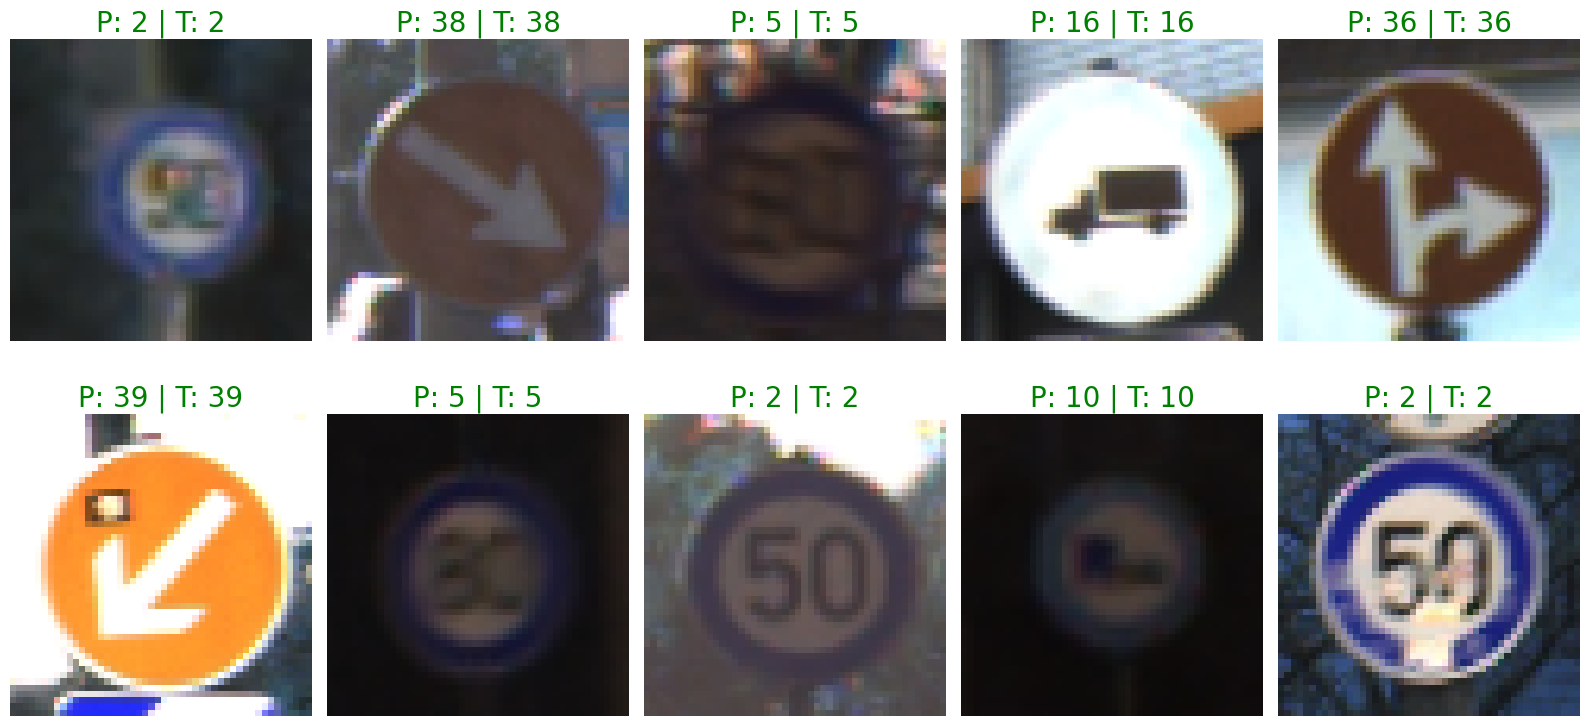

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# ------------------------------
# Load your saved model
# ------------------------------
model = load_model("traffic_sign_classifier.h5")

# ------------------------------
# GTSRB class names
# ------------------------------
class_names = [
"Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
"Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
"End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
"No passing", "No passing for vehicles over 3.5 tons", "Right-of-way at next intersection",
"Priority road", "Yield", "Stop", "No vehicles", "Vehicles over 3.5 tons prohibited",
"No entry", "General caution", "Dangerous curve left", "Dangerous curve right",
"Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
"Road work", "Traffic signals", "Pedestrians", "Children crossing",
"Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
"End of all speed and passing limits", "Turn right ahead", "Turn left ahead",
"Ahead only", "Go straight or right", "Go straight or left", "Keep right",
"Keep left", "Roundabout mandatory", "End of no-passing",
"End of no-passing for vehicles > 3.5 tons"
]

# ------------------------------
# Convert validation labels
# ------------------------------
y_true = np.argmax(y_val, axis=1)

# Pick 10 random samples
indices = np.random.choice(len(X_val), 10, replace=False)

plt.figure(figsize=(16, 8))

for i, idx in enumerate(indices):
    img = X_val[idx]  # (48,48,3)
    true_label = y_true[idx]

    # Predict
    pred = model.predict(img.reshape(1, 48, 48, 3), verbose=0)
    pred_label = np.argmax(pred)

    # Plot image
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # Green if correct, Red if wrong
    color = "green" if pred_label == true_label else "red"

    plt.title(f"P: {pred_label} | T: {true_label}",
        color=color,
        fontsize=20
    )

plt.tight_layout()
plt.show()
